## Atmospheric Carbon Dioxide Dry Air Mole Fractions from quasi-continuous measurements at Mauna Loa, Hawaii.

In [64]:
from pathlib import Path

import matplotlib.pyplot as plt
from ipywidgets import interact
import pandas as pd
import seaborn as sns
import numpy as np

from darts import TimeSeries
from darts.dataprocessing.transformers.boxcox import BoxCox
from darts.utils.statistics import extract_trend_and_seasonality, ModelMode


sns.set_style("whitegrid")
Path.cwd()
data_dir = (Path.cwd().parent / ".data").resolve()
assert data_dir.exists()

/var/folders/yl/_h6j91qd4d30w8vyy7hnlvjh0000gn/T/ipykernel_9781/3935367952.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd.read_csv(
/var/folders/yl/_h6j91qd4d30w8vyy7hnlvjh0000gn/T/ipykernel_9781/3935367952.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M').mean()
The provided DatetimeIndex was associated with a timezone, which is currently not supported by xarray. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 600 entries, 1974-05-31 00:00:00+00:00 to 2024-04-30 00:00:00+00:00
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   600 non-null    float64
dtypes: float64(1)
memory usage: 9.4 KB
None


<Axes: xlabel='date'>

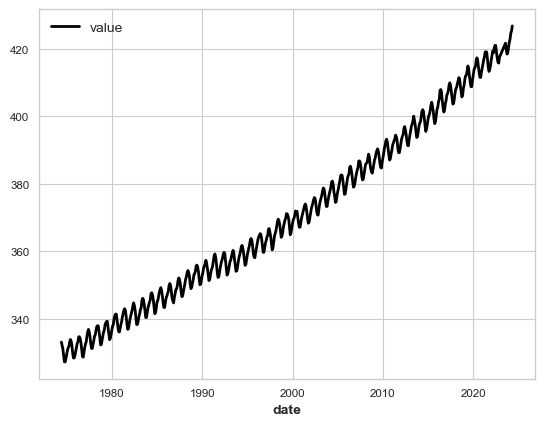

In [65]:
ts = (
    pd.read_csv(
        data_dir / "co2_mlo_surface-insitu_1_ccgg_DailyData.csv",
        delim_whitespace=True,
        header=158,
    )
    .assign(date=lambda df: pd.to_datetime(df['datetime']))
    .drop(columns=["year", "month", "day", "hour", "minute", "second", "datetime", "time_decimal", "midpoint_time"]) # drop redundant cols
    # replace invalid values with NaN
    .assign(
        **{
            col: lambda df, col=col: pd.to_numeric(df[col], errors='coerce').where(df[col] >= 0) for col in ("value", "value_std_dev", "intake_height")
        }
    )
    [["date", "value"]]
    .drop_duplicates(subset=["date"])
    .set_index("date")
    .resample('M').mean()
    # interpolate missing values, TODO: suboptimal predictions
    .interpolate(method='time')
    # drop NaNs at the end and beginning
    .dropna()
    .pipe(lambda df: print(df.info()) or df)
    .pipe(
        lambda df: TimeSeries.from_dataframe(
            df, value_cols=["value"], fill_missing_dates=True,
        )
    )
)

ts.plot()

optimal lambda: -1.4303653756088262


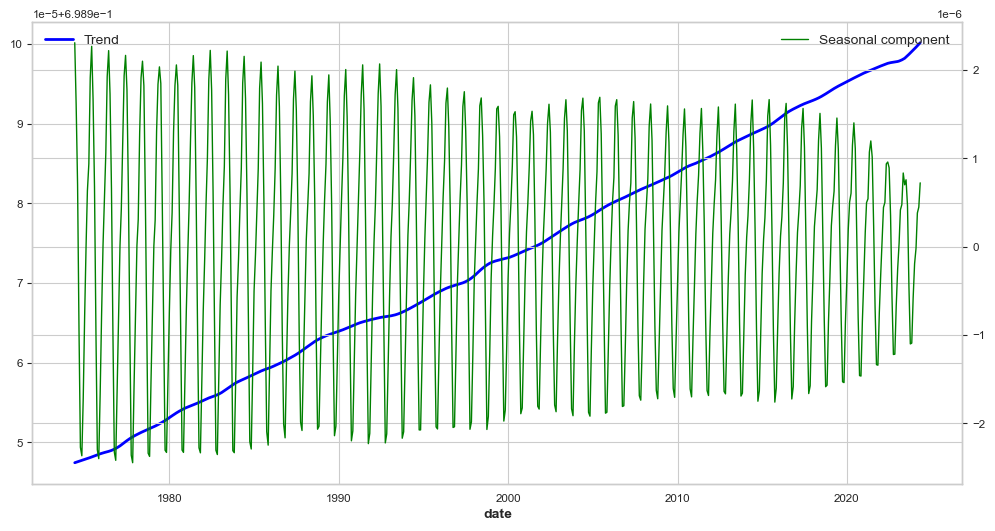

In [66]:
boxcox = BoxCox().fit(ts)
opt_lmbda = boxcox._fitted_params[0][0]
print(
    f"optimal lambda: {opt_lmbda}",
)

transformed_series = boxcox.transform(ts)

# Decompose the transformed series using Darts
trend, seasonal = extract_trend_and_seasonality(transformed_series, method="STL", model=ModelMode.ADDITIVE)
plt.figure(figsize=(12, 6))
ax = trend.plot(label="Trend", lw=2, color="blue")
seasonal.plot(label="Seasonal component", lw=1, ax=ax.twinx(), color="green")
plt.show()

**Note**: Sruggles with finding a lambda that works well for both trend and seasonal components

In [67]:
def plot_boxcox(lmbda):
    transformed_ts = BoxCox(lmbda=lmbda).fit_transform(ts)
    trend, seasonal = extract_trend_and_seasonality(transformed_ts, method="STL", model=ModelMode.ADDITIVE)

    linear_trend = TimeSeries.from_times_and_values(trend.time_index, np.linspace(trend.first_value(), trend.last_value(), len(trend)))

    plt.clf()
    plt.figure(figsize=(12, 6));

    ax = trend.plot(label="Trend", lw=2, color="blue")
    linear_trend.plot(label="Linear trend", lw=1.5, linestyle=":", color="black", ax=ax)
    seasonal.plot(label="Seasonal component", lw=1, ax=ax.twinx(), color="green")

    plt.title("Trend and Seasonal Components")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.close()
interact(plot_boxcox, lmbda=(-2.0, 2.0, 0.01))

interactive(children=(FloatSlider(value=0.0, description='lmbda', max=2.0, min=-2.0, step=0.01), Output()), _d…

<function __main__.plot_boxcox(lmbda)>

**Note**e*: $\lambda > 0$ seems better for increasing homeoskedasticity in the seasonal component, while $\lambda < 0$ provides a better linearization of the trend component

In [68]:
def plot_boxcox(lmbda_trend, lmbda_seasonal):
    # Apply Box-Cox transformation for trend and extract the trend component
    transformed_ts_trend = BoxCox(lmbda=lmbda_trend).fit_transform(ts)
    trend, _ = extract_trend_and_seasonality(transformed_ts_trend, method="STL", model=ModelMode.ADDITIVE)

    # Apply Box-Cox transformation for seasonal, then extract the seasonal component
    transformed_ts_seasonal = BoxCox(lmbda=lmbda_seasonal).fit_transform(ts)
    _, seasonal = extract_trend_and_seasonality(transformed_ts_seasonal, method="STL", model=ModelMode.ADDITIVE)

    # Generate a linear trend line for comparison
    linear_trend = TimeSeries.from_times_and_values(trend.time_index, np.linspace(trend.first_value(), trend.last_value(), len(trend)))

    # Clear the current figure
    plt.clf()
    _ = plt.figure(figsize=(12, 6))

    # Plot the trend and seasonal components
    ax = trend.plot(label="Trend", lw=2, color="blue")
    linear_trend.plot(label="Linear trend", lw=1.5, linestyle=":", color="black", ax=ax)
    seasonal.plot(label="Seasonal component", lw=1, ax=ax.twinx(), color="green")

    plt.title("Trend and Seasonal Components")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.close()
interact(plot_boxcox, lmbda_trend=(-3.0, 2.0, 0.01), lmbda_seasonal=(-2.0, 2.0, 0.01))

interactive(children=(FloatSlider(value=-0.5, description='lmbda_trend', max=2.0, min=-3.0, step=0.01), FloatS…

<function __main__.plot_boxcox(lmbda_trend, lmbda_seasonal)>

**Results from inteactive analysis to get propper lambda values**:
![Separate BoxCox transforms for both seasonal and trend components](../assets/ex03-decomposition.png)

In [69]:
from dataclasses import dataclass
from darts.dataprocessing.transformers import FittableDataTransformer

@dataclass
class SeparateDecompResult:
    lambda_trend: float = None
    lambda_seasonal: float = None
    trend: TimeSeries = None
    seasonal: TimeSeries = None
    boxcox_trend: FittableDataTransformer = None  # [BoxCox]
    boxcox_seasonal: FittableDataTransformer = None  # [BoxCox]

def separate_boxcox_decompose(ts: TimeSeries) -> SeparateDecompResult:
    r = SeparateDecompResult()
    trend, _ = extract_trend_and_seasonality(ts, freq=12, method="STL", model=ModelMode.ADDITIVE)
    r.boxcox_trend = BoxCox().fit(trend)
    r.lambda_trend = r.boxcox_trend._fitted_params[0][0]
    r.trend = r.boxcox_trend.transform(trend)

    _, seasonal = extract_trend_and_seasonality(ts - trend, freq=12, method="naive", model=ModelMode.ADDITIVE)
    r.boxcox_seasonal = BoxCox().fit(seasonal)
    r.lambda_seasonal = r.boxcox_seasonal._fitted_params[0][0]
    r.seasonal = r.boxcox_seasonal.transform(seasonal)

    return r

result = separate_boxcox_decompose(ts)
_, axes = plt.subplots(1, 2, figsize=(12, 8))

result.trend.plot(ax=axes[0], label="Trend", lw=2, color="blue")
result.seasonal.plot(ax=axes[1], label="Seasonal component", lw=1, color="green")
plt.tight_layout()
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/tsa/lib/python3.12/site-packages/scipy/stats/_morestats.py:937: RuntimeWarning: invalid value encountered in log
  logdata = np.log(data)


BracketError: The algorithm terminated without finding a valid bracket. Consider trying different initial points.